ASSIGNMENT – 9

Course: Generative AI

Topic: Creating and Fixing Mode Collapse in a GAN

Name: Ashif Hussain

Program: BCA – Semester V

Department: Computer Applications

University: Alliance University

In [1]:
# Step 1: Bring in all the tools we need
import torch                                   # main tool to build the VAE
import torch.nn as nn                          # layers to build the network
import torch.nn.functional as F                # math functions (like ReLU)
import matplotlib.pyplot as plt                # to draw pictures
import pandas as pd                            # to make the results table
import os                                      # to make folders
from torchvision import datasets, transforms   # to get MNIST images
from torch.utils.data import DataLoader        # to load images in small groups

In [2]:
# Step 2: Set the settings we will use
device = "cuda" if torch.cuda.is_available() else "cpu"   # use GPU if we have it
os.makedirs("results", exist_ok=True)                     # make a folder to save results
LATENT_DIMS = [2, 16, 32]                                 # the 3 latent sizes to test
EPOCHS = 15                                               # how many times we train on all data
NOISE_STD = 0.3                                           # how much noise to add
N_IMAGES = 10                                             # how many test images to use
torch.manual_seed(0)                                      # make results the same every time

In [3]:
# Step 3: Download and load the MNIST images
tf = transforms.ToTensor()                                                    # turn images into numbers (0 to 1)
train_ds = datasets.MNIST("data", train=True, download=True, transform=tf)   # training images
test_ds = datasets.MNIST("data", train=False, download=True, transform=tf)   # test images
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)            # give training images in groups of 128
test_loader = DataLoader(test_ds, batch_size=1000)                           # give test images in groups of 1000

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.13MB/s]


In [4]:
# Step 4: Build the VAE model
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc1 = nn.Linear(784, 512)           # encoder layer 1: 784 pixels -> 512
        self.fc2 = nn.Linear(512, 256)           # encoder layer 2: 512 -> 256
        self.mu = nn.Linear(256, latent_dim)     # makes the mean of the latent code
        self.logvar = nn.Linear(256, latent_dim) # makes the spread of the latent code
        self.fc3 = nn.Linear(latent_dim, 256)    # decoder layer 1: latent -> 256
        self.fc4 = nn.Linear(256, 512)           # decoder layer 2: 256 -> 512
        self.fc5 = nn.Linear(512, 784)           # decoder layer 3: 512 -> 784 pixels

    def encode(self, x):                         # squeeze the image into a small code
        h = F.relu(self.fc2(F.relu(self.fc1(x.view(-1, 784)))))
        return self.mu(h), self.logvar(h)

    def reparam(self, mu, logvar):               # add a little random shake to the code
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def decode(self, z):                         # build the image back from the code
        return torch.sigmoid(self.fc5(F.relu(self.fc4(F.relu(self.fc3(z))))))

    def forward(self, x):                        # run the full VAE: encode, shake, decode
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        return self.decode(z), mu, logvar

In [5]:
# Step 5: Make the loss function and the training function
def vae_loss(recon, x, mu, logvar):
    bce = F.binary_cross_entropy(recon, x.view(-1, 784), reduction="sum")   # how different the new image is from the original
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())           # keeps the latent code neat
    return bce + kld                                                        # total error

def train(latent_dim):
    model = VAE(latent_dim).to(device)                       # make a new VAE
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)      # the helper that improves the model
    for ep in range(EPOCHS):                                 # repeat for each epoch
        total = 0
        for x, _ in train_loader:                            # take images in groups
            x = x.to(device)
            recon, mu, logvar = model(x)                     # run the VAE
            loss = vae_loss(recon, x, mu, logvar)            # find the error
            opt.zero_grad()                                  # clear old learning
            loss.backward()                                  # find how to improve
            opt.step()                                       # improve the model
            total += loss.item()
        print(f"[z={latent_dim}] epoch {ep+1}/{EPOCHS} loss: {total/len(train_ds):.2f}")
    return model.eval()                                      # return the trained model

In [6]:
# Step 6: Make helper functions for reconstruction, error, and pictures
@torch.no_grad()
def reconstruct(model, x):
    mu, _ = model.encode(x.to(device))                       # encode the image to a small code
    return model.decode(mu).cpu().view(-1, 1, 28, 28)        # decode it back to an image

def mse_per_image(a, b):
    return ((a.view(len(a), -1) - b.view(len(b), -1)) ** 2).mean(dim=1)   # error for each image

def show_rows(rows, titles, path, suptitle):
    n = rows[0].shape[0]                                     # how many images in each row
    fig, axes = plt.subplots(len(rows), n, figsize=(1.2 * n, 1.4 * len(rows)))
    for r, (imgs, t) in enumerate(zip(rows, titles)):
        for c in range(n):
            axes[r, c].imshow(imgs[c].squeeze(), cmap="gray", vmin=0, vmax=1)   # draw one image
            axes[r, c].axis("off")                           # hide the axis lines
        axes[r, 0].set_title(t, fontsize=8, loc="left")      # name of the row
    fig.suptitle(suptitle)                                   # big title on top
    plt.tight_layout()
    plt.savefig(path, dpi=130)                               # save the picture
    plt.show()                                               # show it here

def quality_label(mse):
    if mse < 0.005: return "Excellent"
    if mse < 0.01:  return "Very good"
    if mse < 0.02:  return "Good"
    if mse < 0.04:  return "Fair (blurry)"
    return "Poor (blurry)"

In [7]:
# Step 7: Pick 10 test images and make noisy copies of them
test_x, test_y = next(iter(test_loader))                     # take one group of test images
sel = test_x[:N_IMAGES]                                      # keep the first 10 images
g = torch.Generator().manual_seed(1)                         # fixed random seed for the noise
noisy = (sel + NOISE_STD * torch.randn(sel.shape, generator=g)).clamp(0, 1)   # add noise, keep values 0 to 1
results = []                                                 # empty list to save our results later

[z=2] epoch 1/15 loss: 183.49
[z=2] epoch 2/15 loss: 160.55
[z=2] epoch 3/15 loss: 154.34
[z=2] epoch 4/15 loss: 150.98
[z=2] epoch 5/15 loss: 148.79
[z=2] epoch 6/15 loss: 147.21
[z=2] epoch 7/15 loss: 146.17
[z=2] epoch 8/15 loss: 145.16
[z=2] epoch 9/15 loss: 144.56
[z=2] epoch 10/15 loss: 143.75
[z=2] epoch 11/15 loss: 143.35
[z=2] epoch 12/15 loss: 143.02
[z=2] epoch 13/15 loss: 142.29
[z=2] epoch 14/15 loss: 141.90
[z=2] epoch 15/15 loss: 141.64
Compression ratio: 392.0
MSE per image: [0.01634, 0.06155, 0.00382, 0.04565, 0.02759, 0.0054, 0.07158, 0.04553, 0.07314, 0.03653]


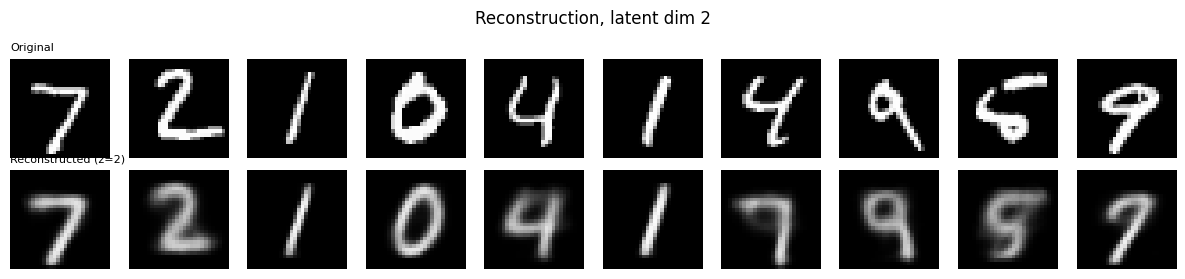

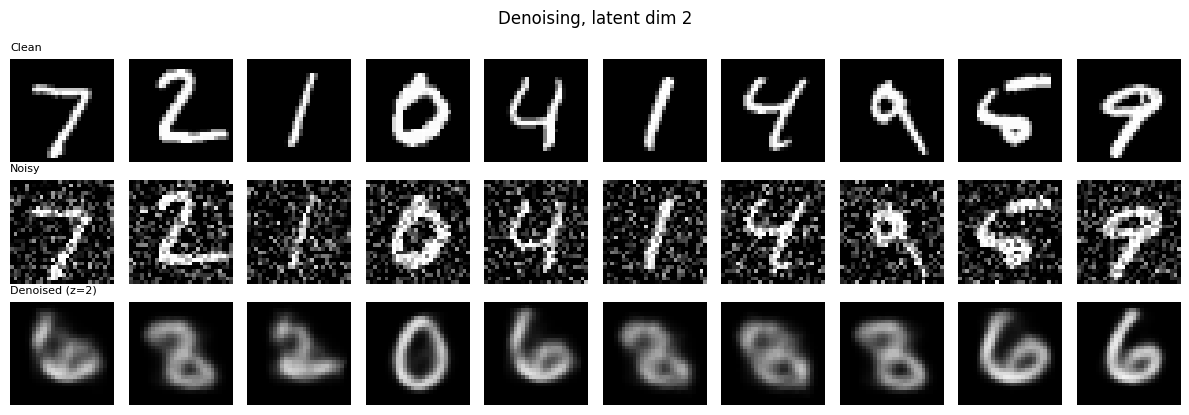

In [8]:
# Step 8: Train the VAE with latent size 2 and test it
D = 2                                                        # latent size for this run
model = train(D)                                             # train the VAE

ratio = 784 / D                                              # Part A: compression ratio
print("Compression ratio:", ratio)

recon = reconstruct(model, sel)                              # Part B: encode and decode 10 images
mse_rec = mse_per_image(recon, sel)                          # error for each image
print("MSE per image:", [round(v, 5) for v in mse_rec.tolist()])
show_rows([sel, recon], ["Original", f"Reconstructed (z={D})"],
          f"results/recon_z{D}.png", f"Reconstruction, latent dim {D}")

denoised = reconstruct(model, noisy)                         # Part C: clean the noisy images
mse_noisy = mse_per_image(noisy, sel).mean().item()          # error of noisy images
mse_den = mse_per_image(denoised, sel).mean().item()         # error of denoised images
show_rows([sel, noisy, denoised], ["Clean", "Noisy", f"Denoised (z={D})"],
          f"results/denoise_z{D}.png", f"Denoising, latent dim {D}")

results.append({                                             # save this run in our table
    "Latent dim": D,
    "Compression ratio": f"{ratio:.1f}:1",
    "Recon MSE": round(mse_rec.mean().item(), 5),
    "Reconstruction quality": quality_label(mse_rec.mean().item()),
    "MSE noisy": round(mse_noisy, 5),
    "MSE denoised": round(mse_den, 5),
})

[z=16] epoch 1/15 loss: 174.59
[z=16] epoch 2/15 loss: 125.56
[z=16] epoch 3/15 loss: 115.32
[z=16] epoch 4/15 loss: 111.04
[z=16] epoch 5/15 loss: 108.63
[z=16] epoch 6/15 loss: 106.85
[z=16] epoch 7/15 loss: 105.58
[z=16] epoch 8/15 loss: 104.60
[z=16] epoch 9/15 loss: 103.74
[z=16] epoch 10/15 loss: 103.03
[z=16] epoch 11/15 loss: 102.49
[z=16] epoch 12/15 loss: 101.96
[z=16] epoch 13/15 loss: 101.52
[z=16] epoch 14/15 loss: 101.13
[z=16] epoch 15/15 loss: 100.81
Compression ratio: 49.0
MSE per image: [0.00444, 0.01532, 0.00152, 0.00737, 0.0089, 0.00167, 0.01477, 0.01982, 0.02991, 0.00903]


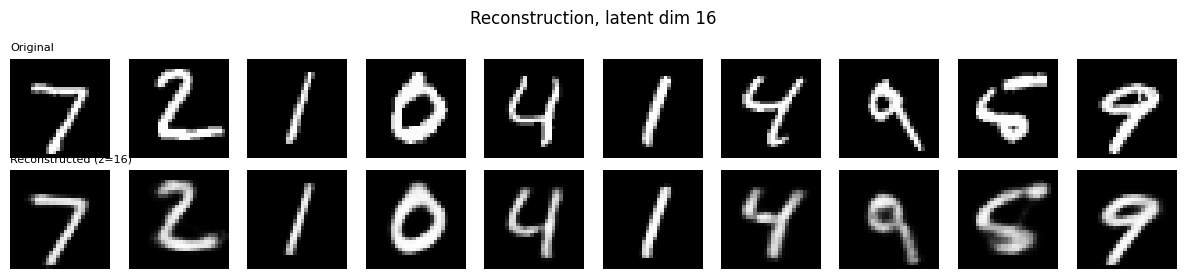

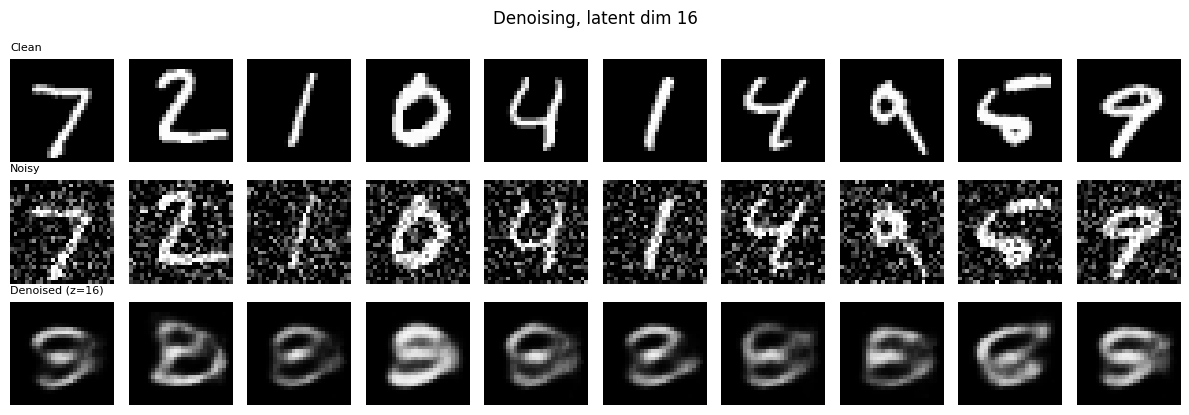

In [9]:
# Step 9: Train the VAE with latent size 16 and test it
D = 16                                                       # latent size for this run
model = train(D)                                             # train the VAE

ratio = 784 / D                                              # Part A: compression ratio
print("Compression ratio:", ratio)

recon = reconstruct(model, sel)                              # Part B: encode and decode 10 images
mse_rec = mse_per_image(recon, sel)                          # error for each image
print("MSE per image:", [round(v, 5) for v in mse_rec.tolist()])
show_rows([sel, recon], ["Original", f"Reconstructed (z={D})"],
          f"results/recon_z{D}.png", f"Reconstruction, latent dim {D}")

denoised = reconstruct(model, noisy)                         # Part C: clean the noisy images
mse_noisy = mse_per_image(noisy, sel).mean().item()          # error of noisy images
mse_den = mse_per_image(denoised, sel).mean().item()         # error of denoised images
show_rows([sel, noisy, denoised], ["Clean", "Noisy", f"Denoised (z={D})"],
          f"results/denoise_z{D}.png", f"Denoising, latent dim {D}")

results.append({                                             # save this run in our table
    "Latent dim": D,
    "Compression ratio": f"{ratio:.1f}:1",
    "Recon MSE": round(mse_rec.mean().item(), 5),
    "Reconstruction quality": quality_label(mse_rec.mean().item()),
    "MSE noisy": round(mse_noisy, 5),
    "MSE denoised": round(mse_den, 5),
})

[z=32] epoch 1/15 loss: 178.82
[z=32] epoch 2/15 loss: 129.16
[z=32] epoch 3/15 loss: 118.55
[z=32] epoch 4/15 loss: 113.39
[z=32] epoch 5/15 loss: 110.34
[z=32] epoch 6/15 loss: 108.10
[z=32] epoch 7/15 loss: 106.55
[z=32] epoch 8/15 loss: 105.30
[z=32] epoch 9/15 loss: 104.24
[z=32] epoch 10/15 loss: 103.48
[z=32] epoch 11/15 loss: 102.74
[z=32] epoch 12/15 loss: 102.23
[z=32] epoch 13/15 loss: 101.73
[z=32] epoch 14/15 loss: 101.40
[z=32] epoch 15/15 loss: 101.04
Compression ratio: 24.5
MSE per image: [0.00482, 0.01145, 0.00218, 0.00938, 0.00812, 0.00151, 0.01528, 0.023, 0.03337, 0.0092]


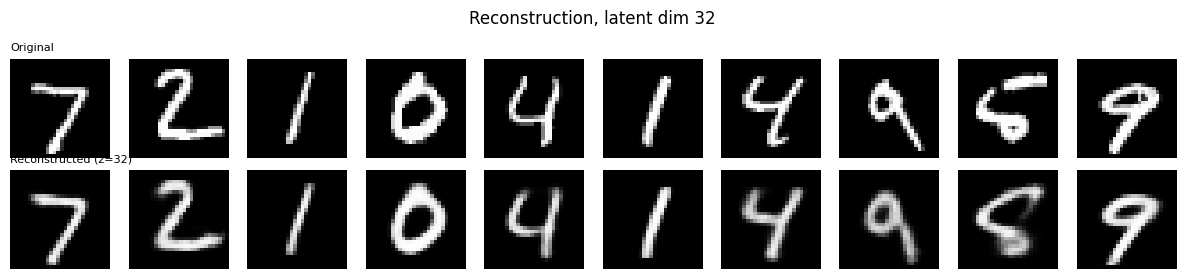

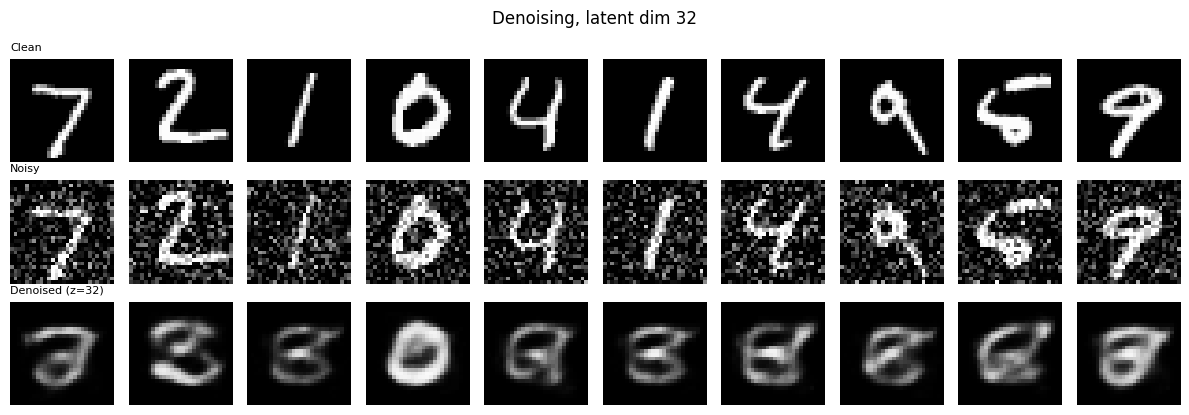

In [10]:
# Step 10: Train the VAE with latent size 32 and test it
D = 32                                                       # latent size for this run
model = train(D)                                             # train the VAE

ratio = 784 / D                                              # Part A: compression ratio
print("Compression ratio:", ratio)

recon = reconstruct(model, sel)                              # Part B: encode and decode 10 images
mse_rec = mse_per_image(recon, sel)                          # error for each image
print("MSE per image:", [round(v, 5) for v in mse_rec.tolist()])
show_rows([sel, recon], ["Original", f"Reconstructed (z={D})"],
          f"results/recon_z{D}.png", f"Reconstruction, latent dim {D}")

denoised = reconstruct(model, noisy)                         # Part C: clean the noisy images
mse_noisy = mse_per_image(noisy, sel).mean().item()          # error of noisy images
mse_den = mse_per_image(denoised, sel).mean().item()         # error of denoised images
show_rows([sel, noisy, denoised], ["Clean", "Noisy", f"Denoised (z={D})"],
          f"results/denoise_z{D}.png", f"Denoising, latent dim {D}")

results.append({                                             # save this run in our table
    "Latent dim": D,
    "Compression ratio": f"{ratio:.1f}:1",
    "Recon MSE": round(mse_rec.mean().item(), 5),
    "Reconstruction quality": quality_label(mse_rec.mean().item()),
    "MSE noisy": round(mse_noisy, 5),
    "MSE denoised": round(mse_den, 5),
})

In [11]:
# Step 11: Show the final results table and save it
df = pd.DataFrame(results)                                   # turn our results into a table
df.to_csv("results/results_table.csv", index=False)          # save the table as a file
df                                                           # show the table here

,Latent dim,Compression ratio,Recon MSE,Reconstruction quality,MSE noisy,MSE denoised
0,2,392.0:1,0.03871,Fair (blurry),0.04741,0.07312
1,16,49.0:1,0.01127,Good,0.04741,0.06356
2,32,24.5:1,0.01183,Good,0.04741,0.05855


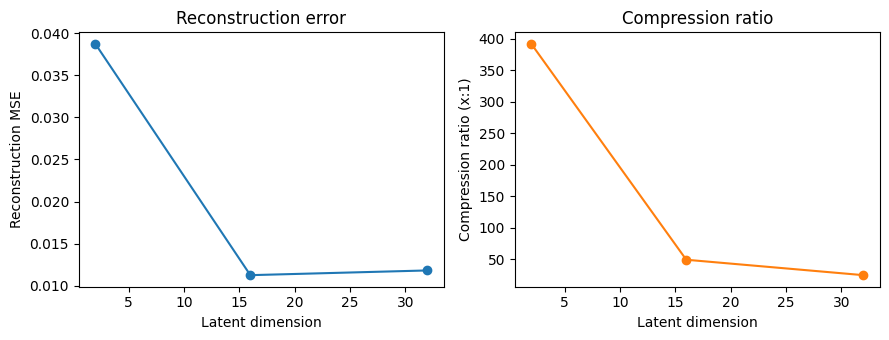

In [12]:
# Step 12: Draw a graph to compare the 3 latent sizes
fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].plot(df["Latent dim"], df["Recon MSE"], "o-")                       # error for each latent size
ax[0].set_xlabel("Latent dimension")
ax[0].set_ylabel("Reconstruction MSE")
ax[0].set_title("Reconstruction error")
ax[1].plot(df["Latent dim"], [784 / d for d in df["Latent dim"]], "o-", color="C1")   # compression for each size
ax[1].set_xlabel("Latent dimension")
ax[1].set_ylabel("Compression ratio (x:1)")
ax[1].set_title("Compression ratio")
plt.tight_layout()
plt.savefig("results/latent_tradeoff.png", dpi=130)                      # save the graph
plt.show()                                                               # show it here

Step 13:

Compression

z=2 gives 392:1, z=16 gives 49:1, and z=32 gives 24.5:1.

A smaller latent size means more compression.


Reconstruction

z=2 has the highest error (0.03871), so the images are blurry.

z=16 has much lower error (0.01127), so the images are good.

z=32 has about the same error (0.01183) as z=16.

So quality improves a lot from 2 to 16, but not from 16 to 32.

The small difference between 16 and 32 is just random variation in training.

Best choice: z=16, because it has low error and still compresses 49 times.

Denoising

The noisy images have an error of 0.04741.

The denoised images have a higher error: 0.07312 (z=2), 0.06356 (z=16) and 0.05855 (z=32).

So by MSE, the VAE did not reduce the error.

The reason is that the VAE was trained on clean images only, and it makes blurry output.

It can also change the shape of the digit, which adds error.

A bigger latent size gives lower error (0.073 → 0.064 → 0.059), so it keeps more of the digit's details.

Look at your denoise pictures: the background should look cleaner, but the digits may look blurry or change shape.

In [13]:
# Step 14: Zip the results folder and download it
import shutil                                                # tool to make zip files
from google.colab import files                               # tool to download files
shutil.make_archive("results", "zip", "results")             # put the results folder in results.zip
files.download("results.zip")                                # download the zip to your computer

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# Step 16: Make one Word document with the table, pictures, and observations
!pip install python-docx -q                                  # install the Word tool
from docx import Document                                    # tool to make Word files
from docx.shared import Inches                               # to set picture size

doc = Document()                                             # make an empty document
doc.add_heading("Assignment 9: VAE for Compression and Denoising", 0)

doc.add_heading("Results Table", 1)
table = doc.add_table(rows=1, cols=len(df.columns))          # make the table
table.style = "Table Grid"
for i, name in enumerate(df.columns):                        # write the column names
    table.rows[0].cells[i].text = str(name)
for _, row in df.iterrows():                                 # write each row of numbers
    cells = table.add_row().cells
    for i, v in enumerate(row):
        cells[i].text = str(v)

doc.add_heading("Reconstruction Pictures", 1)
for d in [2, 16, 32]:
    doc.add_picture(f"results/recon_z{d}.png", width=Inches(6))      # add each picture

doc.add_heading("Denoising Pictures", 1)
for d in [2, 16, 32]:
    doc.add_picture(f"results/denoise_z{d}.png", width=Inches(6))

doc.add_heading("Latent Size Comparison", 1)
doc.add_picture("results/latent_tradeoff.png", width=Inches(6))

doc.add_heading("Observations", 1)
notes = [
    "Compression: z=2 gives 392:1, z=16 gives 49:1, z=32 gives 24.5:1. A smaller latent size gives more compression.",
    "Reconstruction: z=2 has the highest error (0.03871) and blurry images. z=16 (0.01127) and z=32 (0.01183) are much better.",
    "Going from 16 to 32 did not improve quality, so z=16 is the best choice: low error and 49x compression.",
    "Denoising: the noisy images have error 0.04741. The denoised error was 0.07312 (z=2), 0.06356 (z=16), 0.05855 (z=32).",
    "So the VAE did not lower the MSE, because it was trained on clean images only and its output is blurry.",
    "A bigger latent size kept more digit detail, so the denoising error became lower.",
]
for n in notes:
    doc.add_paragraph(n, style="List Bullet")

doc.save("Assignment9.docx")                                 # save the Word file
files.download("Assignment9.docx")                           # download it

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.2 MB/s eta 0:00:00


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>